In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120
})
PALETTE = ['#1B4332', '#B87333', '#D4A574', '#2D3436', '#5C8A4D']

In [2]:
df = pd.read_csv('../data/housing.csv')
print(df.shape)
df.head()

(5000, 6)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area Income          5000 non-null   float64
 1   Area House Age       5000 non-null   float64
 2   Area No of Rooms     5000 non-null   float64
 3   Area No of Bedrooms  5000 non-null   float64
 4   Area Population      5000 non-null   float64
 5   Price                5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [4]:
df.describe().round(2)

In [5]:
df.isnull().sum()

In [6]:
df.duplicated().sum()

In [7]:
features = ['Area Income', 'Area House Age', 'Area No of Rooms', 'Area No of Bedrooms', 'Area Population']
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers}")

Area Income: 32
Area House Age: 25
Area No of Rooms: 24
Area No of Bedrooms: 0
Area Population: 30


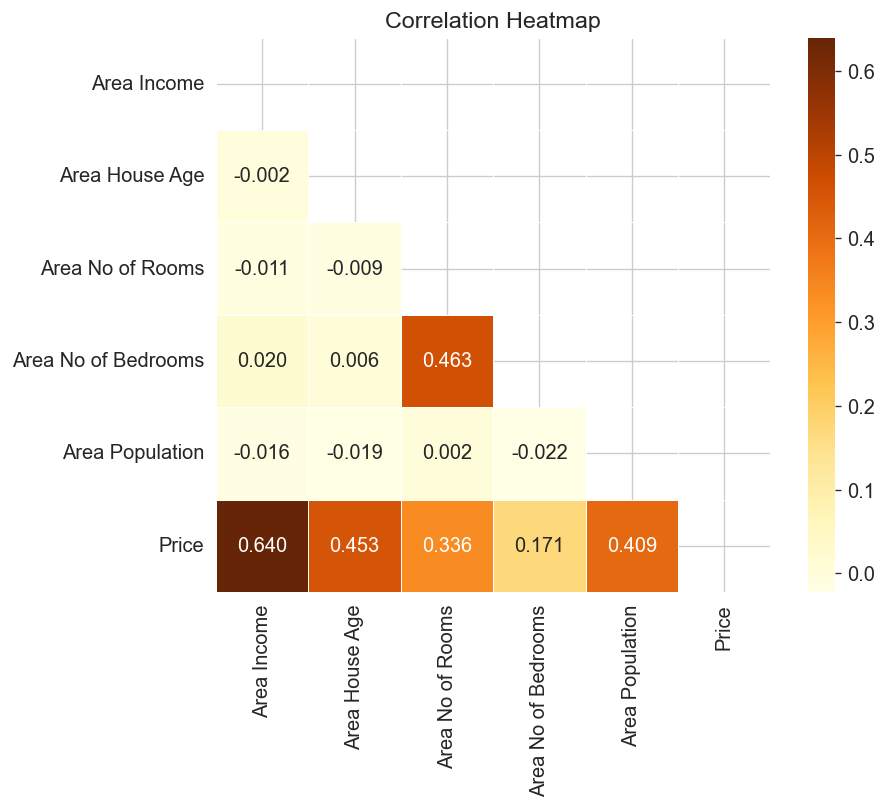

In [8]:
plt.figure(figsize=(8, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='YlOrBr', linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.show()

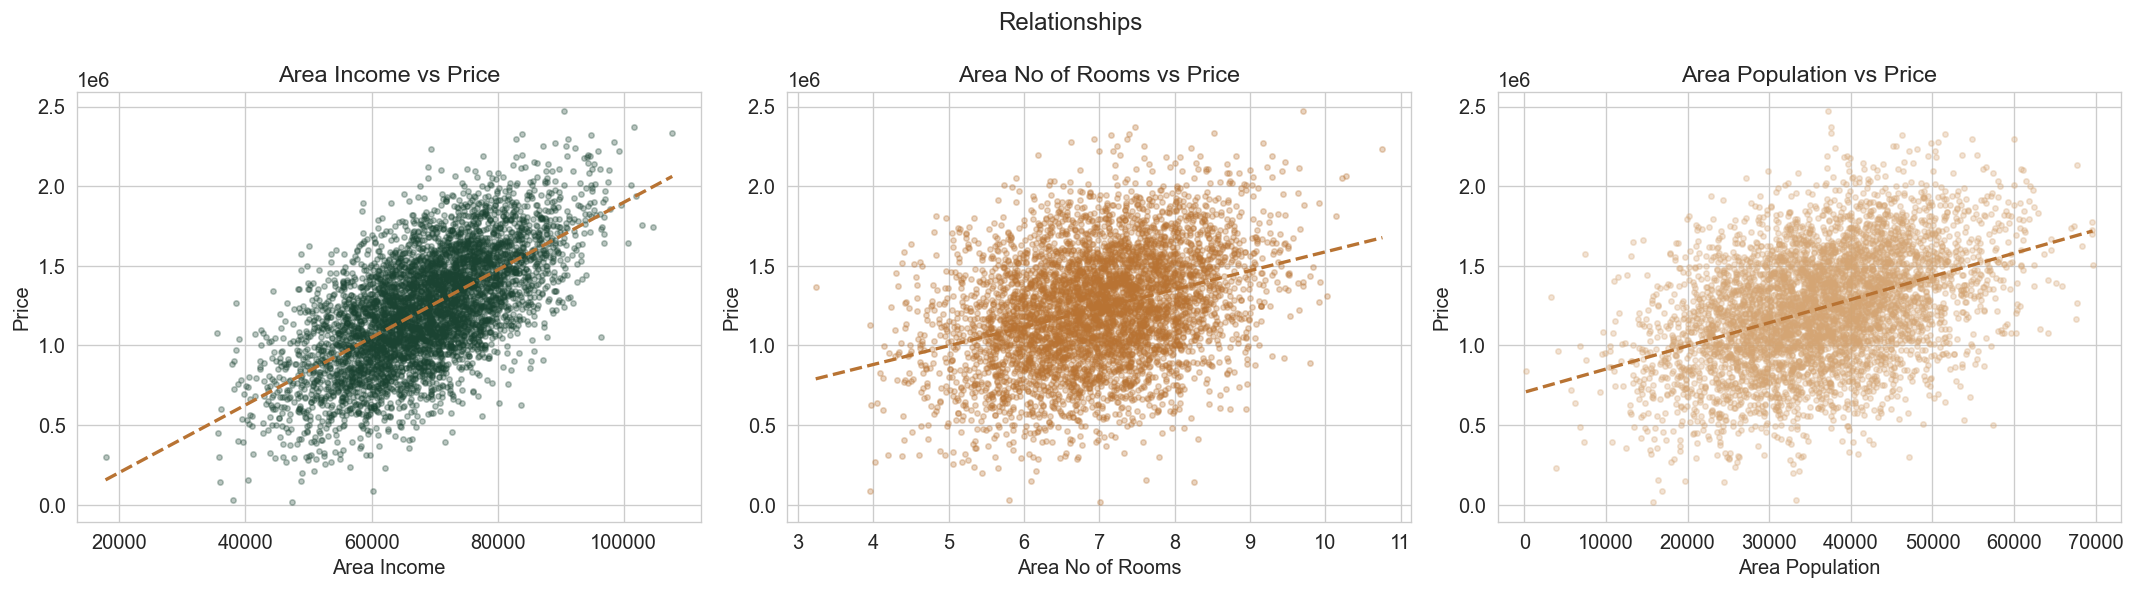

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_features = ['Area Income', 'Area No of Rooms', 'Area Population']
for i, feat in enumerate(scatter_features):
    axes[i].scatter(df[feat], df['Price'], alpha=0.3, color=PALETTE[i], s=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{feat} vs Price')
    z = np.polyfit(df[feat], df['Price'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df[feat])
    axes[i].plot(x_sorted, p(x_sorted), color='#B87333', linewidth=2, linestyle='--')
plt.suptitle('Relationships')
plt.tight_layout()
plt.show()

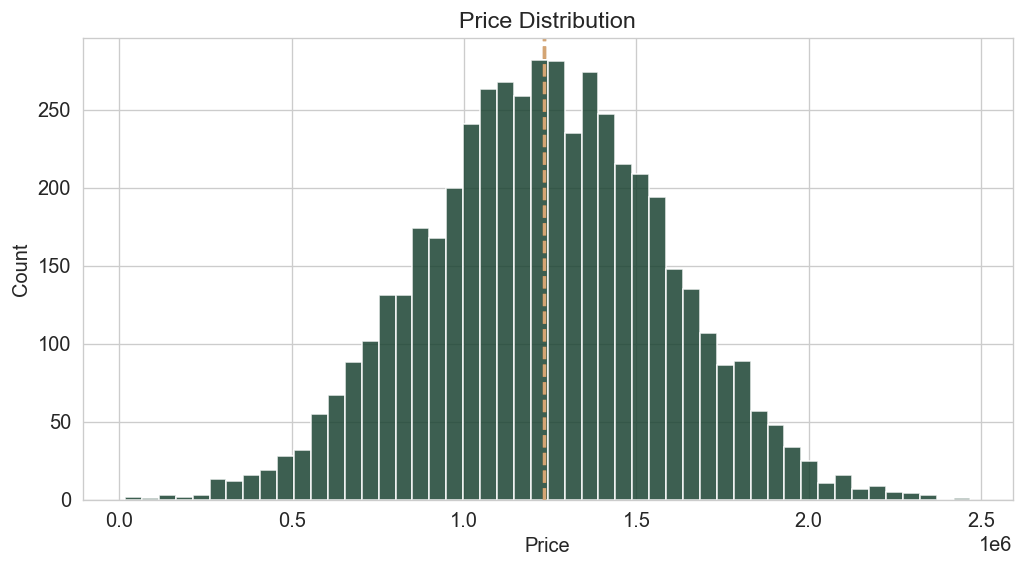

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df['Price'], bins=50, color=PALETTE[0], edgecolor='white', alpha=0.85)
plt.axvline(df['Price'].mean(), color=PALETTE[1], linestyle='--', linewidth=2)
plt.axvline(df['Price'].median(), color=PALETTE[2], linestyle='--', linewidth=2)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution')
plt.show()

In [11]:
X = df[features]
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

In [14]:
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(rmse)
print(r2)

100444.06054865339
0.9179971706985147


In [15]:
model_unscaled = LinearRegression()
model_unscaled.fit(X_train, y_train)
print(model_unscaled.intercept_)
print(model_unscaled.coef_)

-2635072.900916771
[2.16522058e+01 1.64666481e+05 1.19624012e+05 2.44037761e+03
 1.52703134e+01]


In [16]:
os.makedirs('../model', exist_ok=True)
joblib.dump(model, '../model/house_price_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')
joblib.dump(features, '../model/feature_names.pkl')
joblib.dump({'rmse': rmse, 'r2': r2}, '../model/metrics.pkl')